In [7]:
import torch
import torch.nn as nn
from torch.optim import SGD
import matplotlib.pyplot as plt

In [8]:
# dados inventados para treinamento
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

In [9]:
# convertendo em tensor
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [10]:
# criando a classe da rede neural
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # criando uma camada linear (2 dados de entrada e 8 de saida)
        self.layer1 = nn.Linear(2,8)
        # função de ativação relu
        self.activation = nn.ReLU()
        # 8 dados de entrada 1 de saída (resposta)
        self.layer2 = nn.Linear(8,1)

    # passagem de uma camada para outra
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

In [11]:
# instanciando o modelo
model = NeuralNetwork()

In [13]:
# definindo a função de loss
loss_func = nn.MSELoss()

# definindo optmizador
opt = SGD(model.parameters(), lr= 0.001)

In [14]:
losses = []
# 50 épocas
for _ in range(50):
    # gradientes em zero antes de cada época
    opt.zero_grad()
    loss_value = loss_func(model(X), Y)
    loss_value.backward()

    # atualiza os pesos
    opt.step()
    losses.append(loss_value.detach().numpy())

Text(0, 0.5, 'loss')

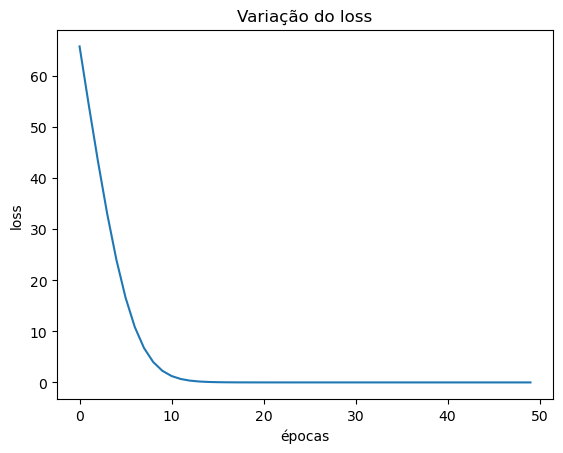

In [15]:
plt.plot(losses)
plt.title('Variação do loss')
plt.xlabel('épocas')
plt.ylabel('loss')